# Day 6.1: Decision Tree Concepts

## Table of Contents
- [Introduction to Decision Trees](#introduction-to-decision-trees)
- [Decision Tree Structure](#decision-tree-structure)
- [Decision Trees for Classification](#decision-trees-for-classification)
  - [Splitting Criteria: Gini Impurity](#splitting-criteria-gini-impurity)
  - [Splitting Criteria: Information Gain & Entropy](#splitting-criteria-information-gain--entropy)
  - [Mathematical Formulations](#mathematical-formulations)
- [Decision Trees for Regression](#decision-trees-for-regression)
  - [Variance Reduction & MSE](#variance-reduction--mse)
  - [Differences from Classification Trees](#differences-from-classification-trees)
- [Visualizing Decision Trees](#visualizing-decision-trees)
  - [Methods for Visualization](#methods-for-visualization)
  - [Interpreting Tree Visualizations](#interpreting-tree-visualizations)
- [Comparison with Previously Learned Models](#comparison-with-previously-learned-models)

## Introduction to Decision Trees

Decision trees are versatile machine learning algorithms used for both classification and regression tasks. They're named "decision trees" because they mimic a flowchart-like structure where decisions branch out, eventually leading to predictions.

In [15]:
# Import libraries we'll use throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris#, load_boston, load_diabetes
from sklearn.metrics import accuracy_score, mean_squared_error

### Key Advantages of Decision Trees

- **Interpretability**: Easy to understand and explain to non-technical stakeholders
- **No preprocessing required**: Can handle both numerical and categorical data without scaling
- **Non-linearity**: Can capture complex, non-linear relationships
- **Feature interaction**: Automatically model interactions between features

## Decision Tree Structure

A decision tree consists of the following components:

- **Root Node**: The topmost node representing the entire dataset
- **Internal Nodes (Decision Nodes)**: Represent a test on a feature
- **Branches**: Represent the outcome of the test
- **Leaf Nodes (Terminal Nodes)**: Represent the final prediction

### Tree Construction Process

Decision trees are built using a recursive partitioning process:

1. Start with the entire dataset at the root node
2. Select the best feature and split point that divides the data most effectively
3. Create child nodes based on the split
4. Recursively repeat for each child node until stopping criteria are met

### Intuitive Understanding

Think of a decision tree like playing the game "20 Questions":

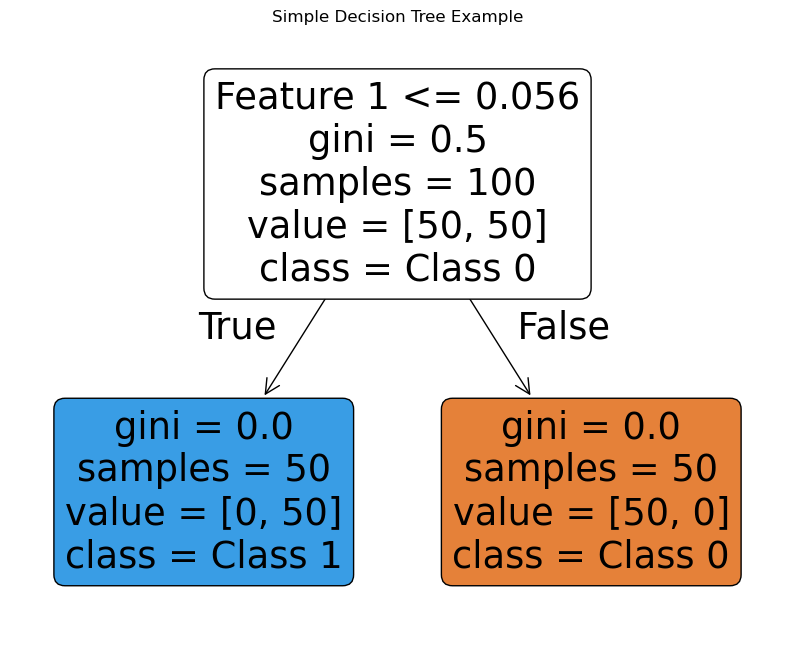

In [7]:
# Simple visualization of a decision tree concept
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus

# Let's create a simple toy dataset
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, 
                          n_informative=2, random_state=1, n_clusters_per_class=1)

# Train a simple decision tree
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

# Visualization
plt.figure(figsize=(10, 8))
plot_tree(clf, filled=True, feature_names=['Feature 1', 'Feature 2'], 
          class_names=['Class 0', 'Class 1'], rounded=True)
plt.title("Simple Decision Tree Example")
plt.show()

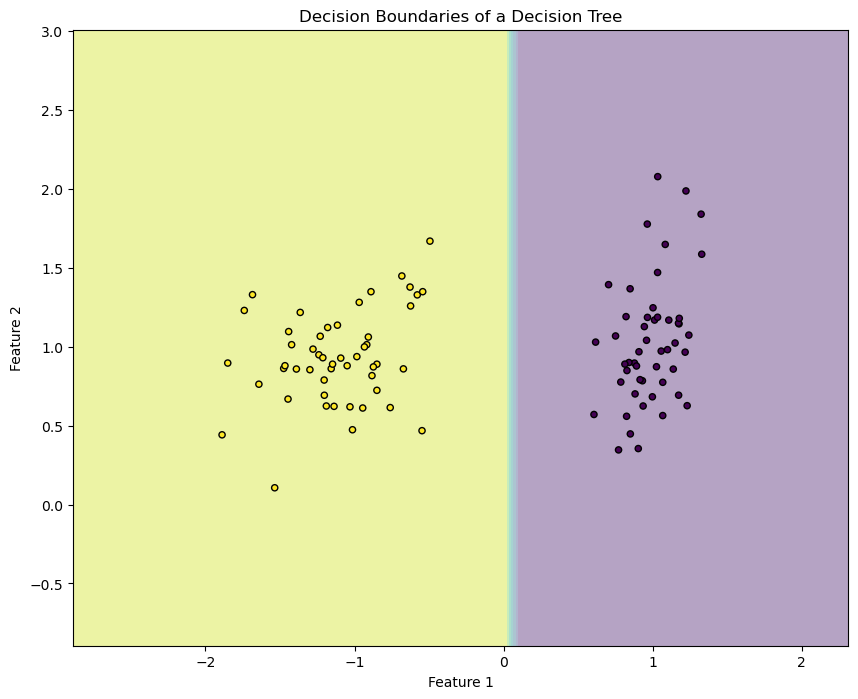

In [8]:
# Plot the decision boundary
plt.figure(figsize=(10, 8))
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
plt.title("Decision Boundaries of a Decision Tree")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Knowledge Check: Decision Tree Structure
1. What are the four main components of a decision tree?
2. How is a decision tree similar to the game "20 Questions"?
3. What is the process by which decision trees are constructed?
4. Why might decision trees be preferable when model interpretation is important?

## Decision Trees for Classification

In classification trees, the goal is to split the data into increasingly "pure" nodes, where purity refers to how homogeneous the class labels are within each node.

### Splitting Criteria: Gini Impurity

**Gini impurity** measures the probability of incorrectly classifying a randomly chosen element if it were randomly labeled according to the distribution of labels in the node.

$$\text{Gini} = 1 - \sum_{i=1}^{k} (p_i)^2$$

Where $p_i$ is the proportion of samples belonging to class $i$ in that node and $k$ is the number of classes.

- Perfect purity (all samples in one class): Gini = 0
- Maximum impurity (equal distribution): Gini = $1 - \frac{1}{k}$

The algorithm chooses splits that minimize the weighted sum of the Gini impurity of the child nodes.

### Splitting Criteria: Information Gain & Entropy

**Entropy** measures the amount of disorder or uncertainty in a node:

$$\text{Entropy} = -\sum_{i=1}^{k} p_i \log_2(p_i)$$

**Information Gain** is the reduction in entropy achieved by a split:

$$\text{IG} = \text{Entropy(parent)} - \sum \text{WeightedEntropy(children)}$$

The algorithm chooses splits that maximize Information Gain.

In [9]:
# Let's demonstrate the calculation of Gini impurity and Entropy
def calculate_gini(class_distribution):
    """Calculate Gini impurity from a class distribution array"""
    proportions = class_distribution / np.sum(class_distribution)
    return 1 - np.sum(proportions**2)

def calculate_entropy(class_distribution):
    """Calculate entropy from a class distribution array"""
    proportions = class_distribution / np.sum(class_distribution)
    # Handle 0 proportions (log(0) is undefined)
    log_vals = np.log2(proportions, out=np.zeros_like(proportions), where=(proportions!=0))
    return -np.sum(proportions * log_vals)

In [10]:
# Example: Node with 10 samples of class A and 0 of class B (pure)
pure_node = np.array([10, 0])
print(f"Pure node - Gini impurity: {calculate_gini(pure_node):.4f}")
print(f"Pure node - Entropy: {calculate_entropy(pure_node):.4f}")

Pure node - Gini impurity: 0.0000
Pure node - Entropy: -0.0000


In [11]:
# Example: Node with 5 samples of class A and 5 of class B (impure)
impure_node = np.array([5, 5])
print(f"Impure node - Gini impurity: {calculate_gini(impure_node):.4f}")
print(f"Impure node - Entropy: {calculate_entropy(impure_node):.4f}")

Impure node - Gini impurity: 0.5000
Impure node - Entropy: 1.0000


In [12]:
# Example: Node with 7 samples of class A and 3 of class B (somewhat impure)
somewhat_impure = np.array([7, 3])
print(f"Somewhat impure node - Gini impurity: {calculate_gini(somewhat_impure):.4f}")
print(f"Somewhat impure node - Entropy: {calculate_entropy(somewhat_impure):.4f}")

Somewhat impure node - Gini impurity: 0.4200
Somewhat impure node - Entropy: 0.8813


In [13]:
# Example of Information Gain calculation
parent = np.array([5, 5])  # Parent node with 5 of each class
left_child = np.array([4, 1])  # Left child after split
right_child = np.array([1, 4])  # Right child after split

parent_entropy = calculate_entropy(parent)
left_weight = np.sum(left_child) / np.sum(parent)
right_weight = np.sum(right_child) / np.sum(parent)
weighted_child_entropy = left_weight * calculate_entropy(left_child) + right_weight * calculate_entropy(right_child)
information_gain = parent_entropy - weighted_child_entropy

print(f"\nParent entropy: {parent_entropy:.4f}")
print(f"Weighted child entropy: {weighted_child_entropy:.4f}")
print(f"Information Gain: {information_gain:.4f}")


Parent entropy: 1.0000
Weighted child entropy: 0.7219
Information Gain: 0.2781


### Mathematical Formulations

When selecting the best feature to split on, the algorithm evaluates all possible features and all possible split points, choosing the one that optimizes the criterion (minimizes impurity or maximizes information gain).

For each potential split:
1. Calculate the impurity measure (Gini or Entropy) for the parent node
2. Calculate the weighted impurity of the resulting child nodes
3. For Gini: Choose the split that minimizes weighted child impurity
4. For Entropy: Choose the split that maximizes information gain

In [16]:
# Demonstration with Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train trees with different criteria
gini_tree = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
entropy_tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

gini_tree.fit(X_train, y_train)
entropy_tree.fit(X_train, y_train)

# Compare performance
y_pred_gini = gini_tree.predict(X_test)
y_pred_entropy = entropy_tree.predict(X_test)

print(f"Gini criterion accuracy: {accuracy_score(y_test, y_pred_gini):.4f}")
print(f"Entropy criterion accuracy: {accuracy_score(y_test, y_pred_entropy):.4f}")

Gini criterion accuracy: 1.0000
Entropy criterion accuracy: 0.9778


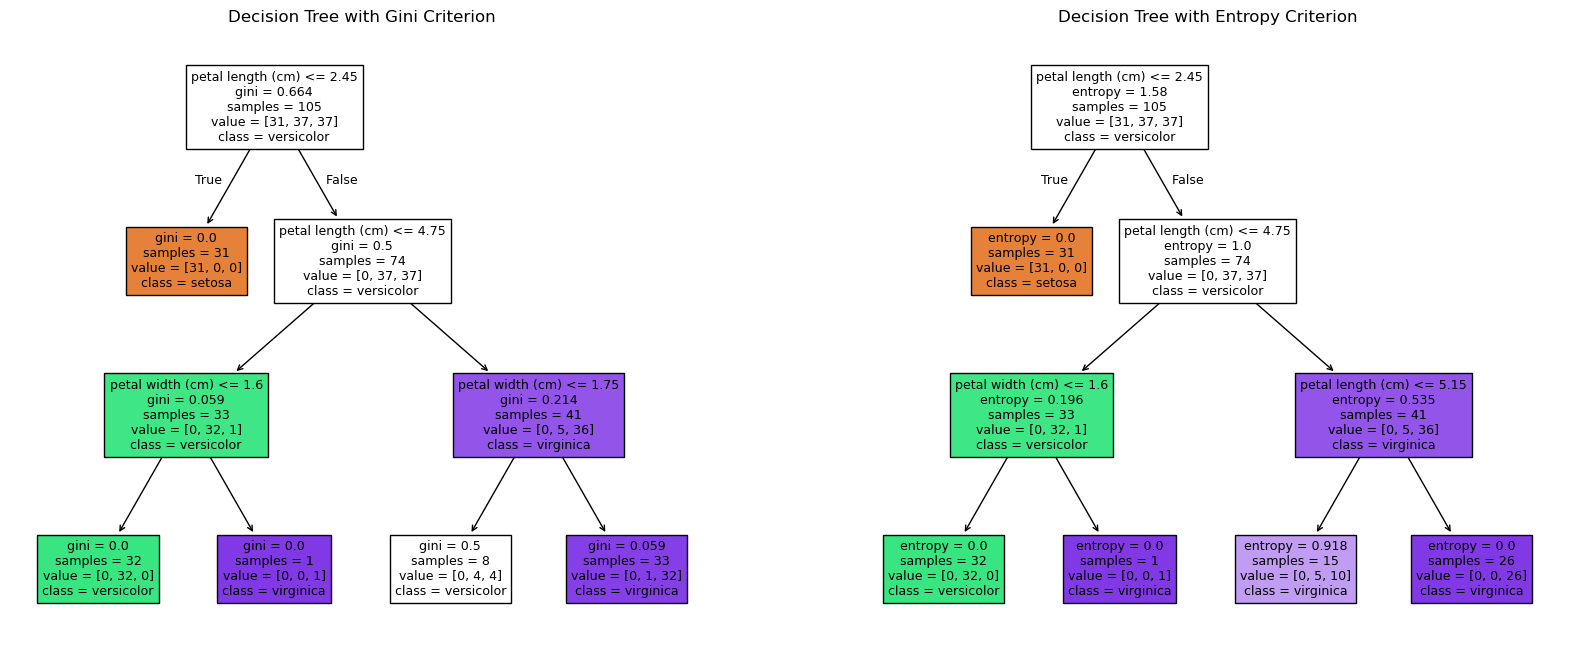

In [17]:
# Visualize both trees
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
plot_tree(gini_tree, filled=True, feature_names=iris.feature_names, 
          class_names=iris.target_names, ax=axes[0])
axes[0].set_title("Decision Tree with Gini Criterion")

plot_tree(entropy_tree, filled=True, feature_names=iris.feature_names, 
          class_names=iris.target_names, ax=axes[1])
axes[1].set_title("Decision Tree with Entropy Criterion")
plt.show()

### Knowledge Check: Decision Trees for Classification
1. What is Gini impurity and how is it calculated?
2. How does Entropy differ from Gini impurity as a splitting criterion?
3. Calculate the Gini impurity for a node with 8 samples of class A and 2 of class B.
4. What does it mean when a node has Gini impurity = 0 or Entropy = 0?
5. In practice, do Gini and Entropy criteria typically lead to very different trees?

## Decision Trees for Regression

While classification trees predict categorical outputs, regression trees predict continuous values.

### Variance Reduction & MSE

For regression trees, the typical splitting criterion is the reduction in variance or Mean Squared Error (MSE):

$$\text{Variance} = \frac{1}{N}\sum_{i=1}^{N}(y_i - \bar{y})^2$$

For a potential split, the algorithm computes:

$$\text{MSE}_{\text{split}} = \frac{N_{\text{left}}}{N_{\text{parent}}}\text{MSE}_{\text{left}} + \frac{N_{\text{right}}}{N_{\text{parent}}}\text{MSE}_{\text{right}}$$

The split that minimizes this weighted MSE is chosen.

In [18]:
# Example with a regression dataset
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a regression tree
regr_tree = DecisionTreeRegressor(max_depth=3, random_state=42)
regr_tree.fit(X_train, y_train)

# Evaluate performance
y_pred = regr_tree.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {np.sqrt(mse):.2f}")

Mean Squared Error: 3616.77
Root Mean Squared Error: 60.14


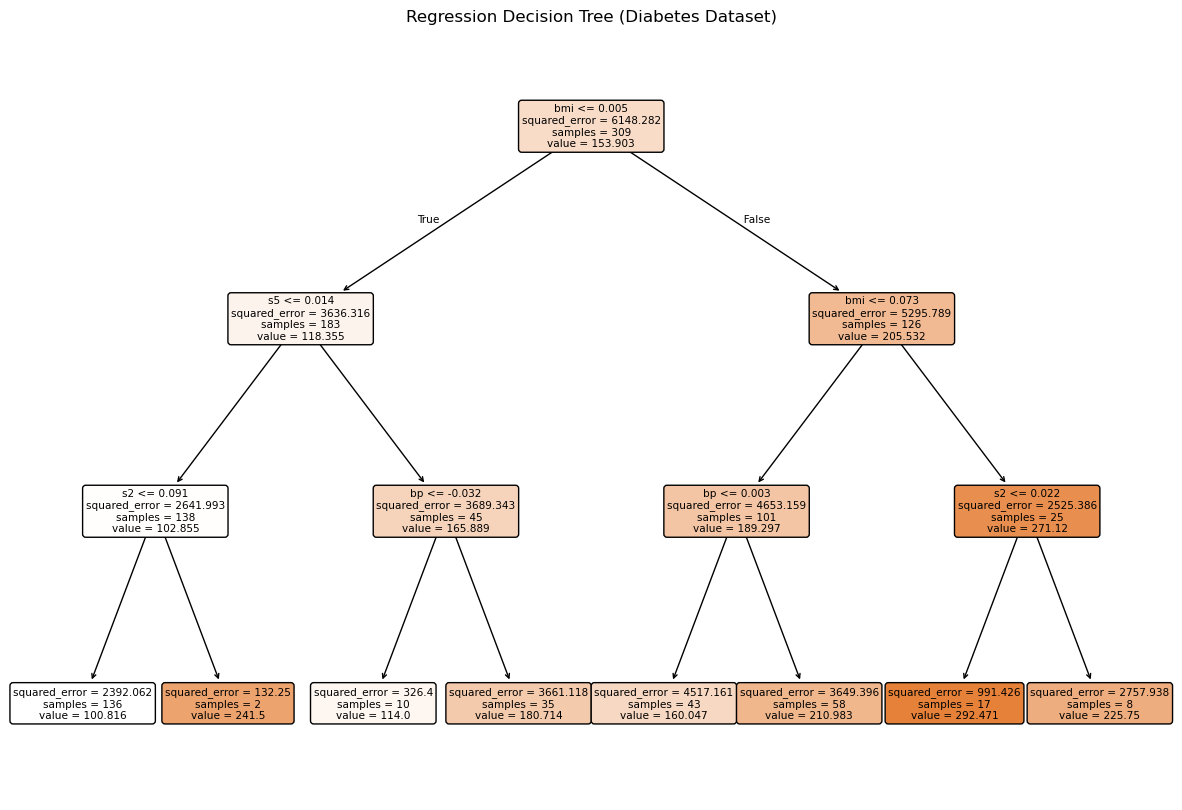

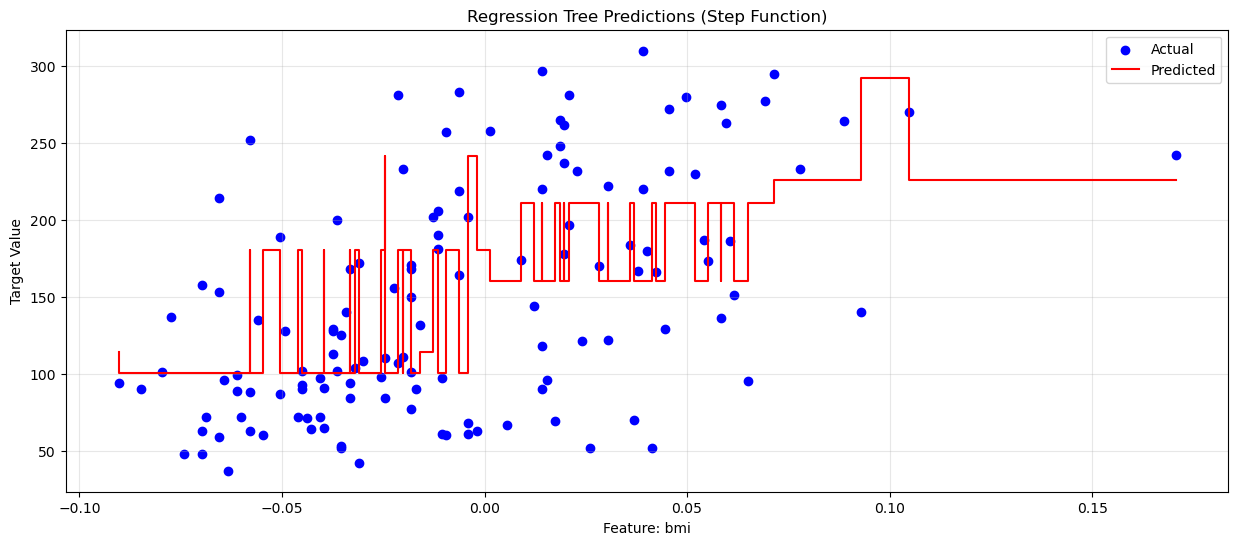

In [22]:
# Visualize the tree
plt.figure(figsize=(15, 10))
plot_tree(regr_tree, filled=True, feature_names=diabetes.feature_names, rounded=True)
plt.title("Regression Decision Tree (Diabetes Dataset)")
plt.show()

# Let's demonstrate how predictions work in a regression tree
# by plotting predictions vs actual for a single feature
if X.shape[1] > 0:  # Ensure there's at least one feature
    # Choose one feature for demonstration
    feature_idx = 2  # You can change this to any valid feature index
    
    # Sort the feature values for plotting
    sorted_idx = np.argsort(X_test[:, feature_idx])
    sorted_X = X_test[sorted_idx, feature_idx]
    sorted_y = y_test[sorted_idx]
    sorted_y_pred = y_pred[sorted_idx]
    
    plt.figure(figsize=(15, 6))
    plt.scatter(sorted_X, sorted_y, c='b', label='Actual')
    plt.step(sorted_X, sorted_y_pred, c='r', label='Predicted')
    plt.xlabel(f'Feature: {diabetes.feature_names[feature_idx]}')
    plt.ylabel('Target Value')
    plt.title('Regression Tree Predictions (Step Function)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### Differences from Classification Trees

Key differences between regression and classification trees:

| Aspect | Classification Trees | Regression Trees |
|--------|----------------------|------------------|
| Prediction Type | Class label or probabilities | Continuous value |
| Splitting Criterion | Gini impurity or Entropy | Variance reduction or MSE |
| Leaf Node Output | Majority class or class distribution | Mean/median of target values |
| Prediction Pattern | Decision boundaries between classes | Piecewise constant function |

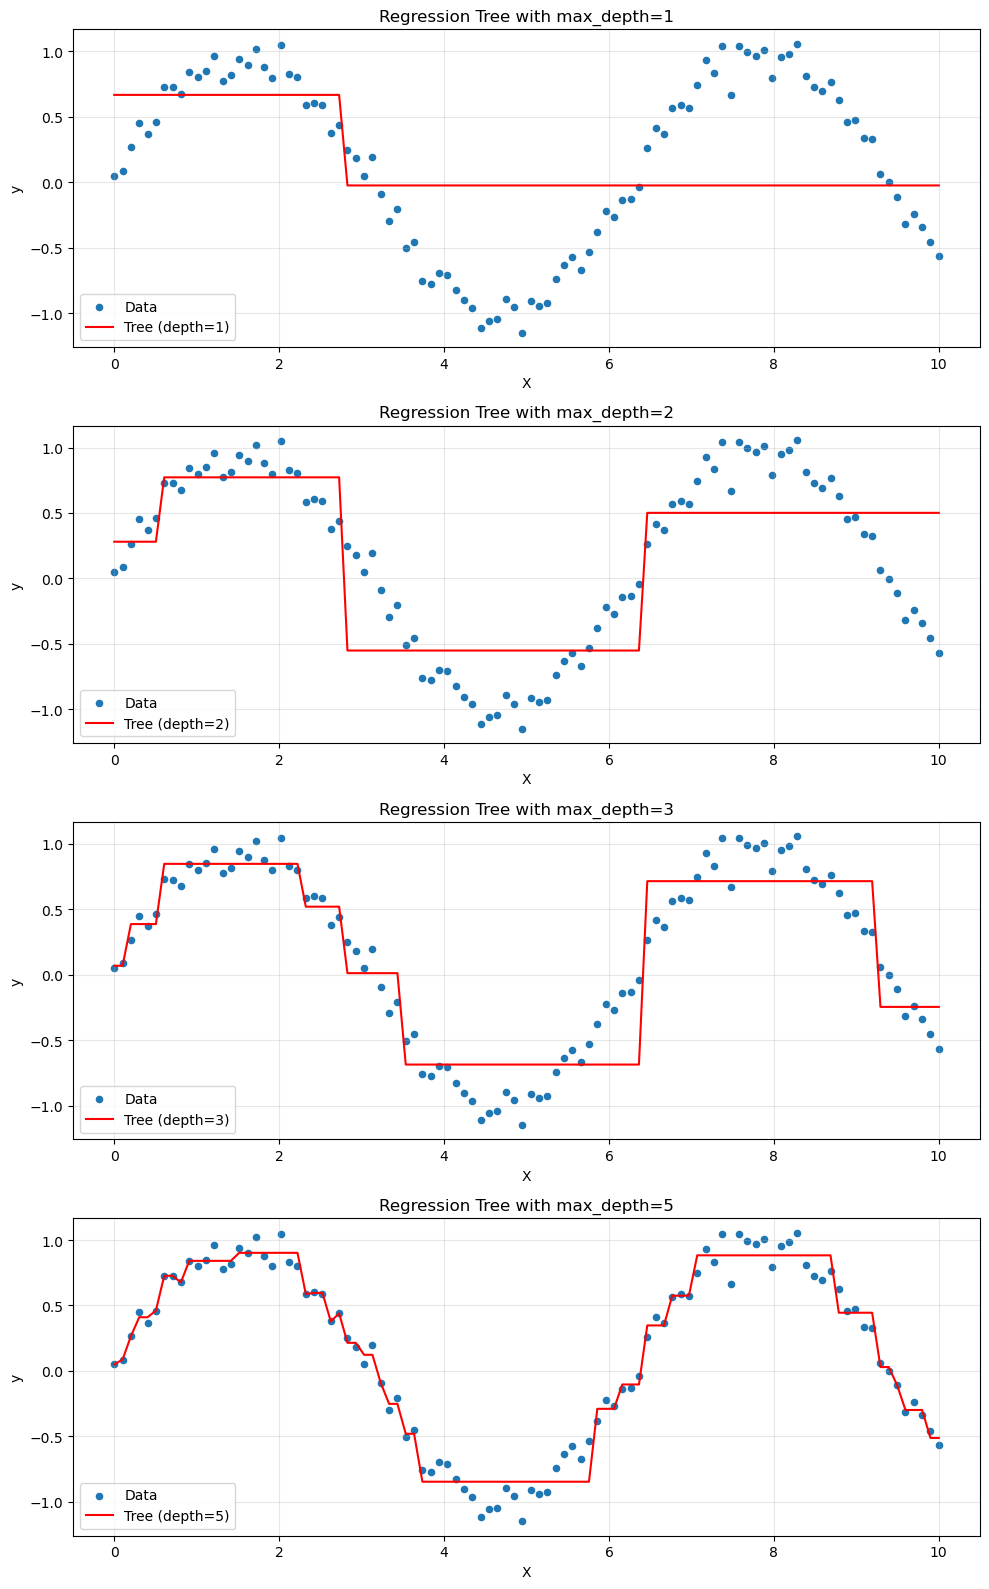

In [23]:
# Simple demonstration of the "step-like" predictions in regression trees
# Let's create a simple 1D regression problem
np.random.seed(42)
X_simple = np.linspace(0, 10, 100).reshape(-1, 1)
y_simple = np.sin(X_simple.ravel()) + np.random.normal(0, 0.1, 100)

# Fit regression trees of different depths
depths = [1, 2, 3, 5]
fig, axes = plt.subplots(len(depths), 1, figsize=(10, 4*len(depths)))

for i, depth in enumerate(depths):
    reg_tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg_tree.fit(X_simple, y_simple)
    
    # Predict
    y_pred = reg_tree.predict(X_simple)
    
    # Plot
    axes[i].scatter(X_simple, y_simple, s=20, label='Data')
    axes[i].plot(X_simple, y_pred, color='r', label=f'Tree (depth={depth})')
    axes[i].set_title(f'Regression Tree with max_depth={depth}')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('y')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Knowledge Check: Decision Trees for Regression
1. How do regression trees differ from classification trees in terms of what they predict?
2. What are the main splitting criteria used in regression trees?
3. Why do regression tree predictions often look "blocky" or like step functions?
4. Calculate the MSE for a node with target values [5, 6, 7, 8].
5. Would you expect a very deep regression tree to give smooth or jagged predictions? Why?

## Visualizing Decision Trees

One of the key advantages of decision trees is their interpretability through visualization.

### Methods for Visualization

There are several ways to visualize decision trees in scikit-learn:

1. **Text-based representation**:

In [24]:
# Text representation of a decision tree
iris = load_iris()
X = iris.data
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X, y)

# Text visualization
tree_text = export_text(tree_clf, feature_names=iris.feature_names)
print("Text representation of the tree:")
print(tree_text)

Text representation of the tree:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- class: 1
|   |--- petal width (cm) >  1.75
|   |   |--- class: 2



2. **Matplotlib visualization with plot_tree**:

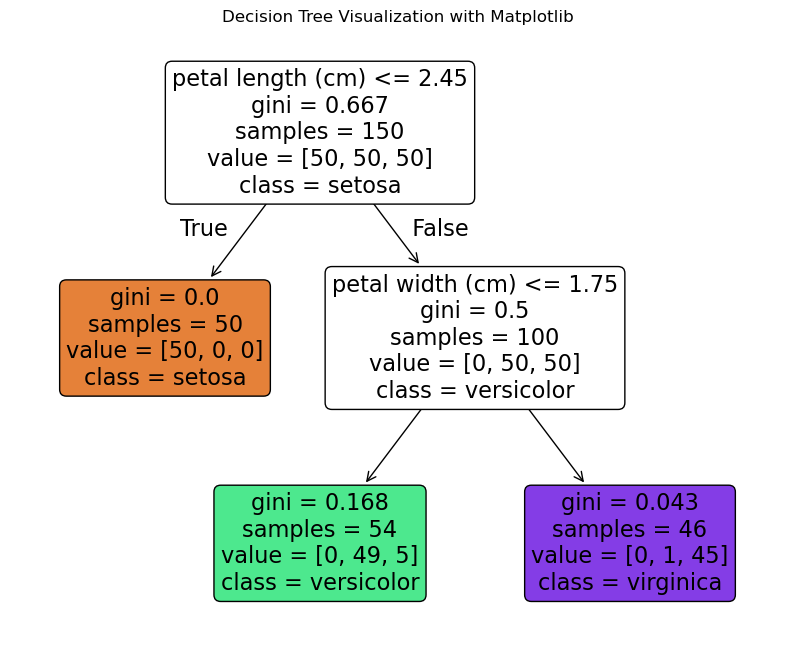

In [26]:
# Graphical visualization using matplotlib
plt.figure(figsize=(10, 8))
plot_tree(tree_clf, filled=True, feature_names=iris.feature_names, 
          class_names=iris.target_names, rounded=True)
plt.title("Decision Tree Visualization with Matplotlib")
plt.show()

3. **Graphviz visualization (more aesthetic, requires Graphviz installation)**:

In [27]:
# Commented out as it requires Graphviz installation
"""
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(tree_clf, out_file=None, 
                           feature_names=iris.feature_names,
                           class_names=iris.target_names,
                           filled=True, rounded=True)
graph = graphviz.Source(dot_data)
graph.render("iris_decision_tree") # Creates a PDF file
graph
"""

'\nfrom sklearn.tree import export_graphviz\nimport graphviz\n\ndot_data = export_graphviz(tree_clf, out_file=None, \n                           feature_names=iris.feature_names,\n                           class_names=iris.target_names,\n                           filled=True, rounded=True)\ngraph = graphviz.Source(dot_data)\ngraph.render("iris_decision_tree") # Creates a PDF file\ngraph\n'

### Interpreting Tree Visualizations

When examining a tree visualization, look for:

1. **The feature and threshold used for splitting at each node**
2. **The impurity measure (Gini/Entropy/MSE) at each node**
3. **The number of samples at each node**
4. **The class distribution (for classification) or predicted value (for regression)**
5. **The depth of the tree and complexity**

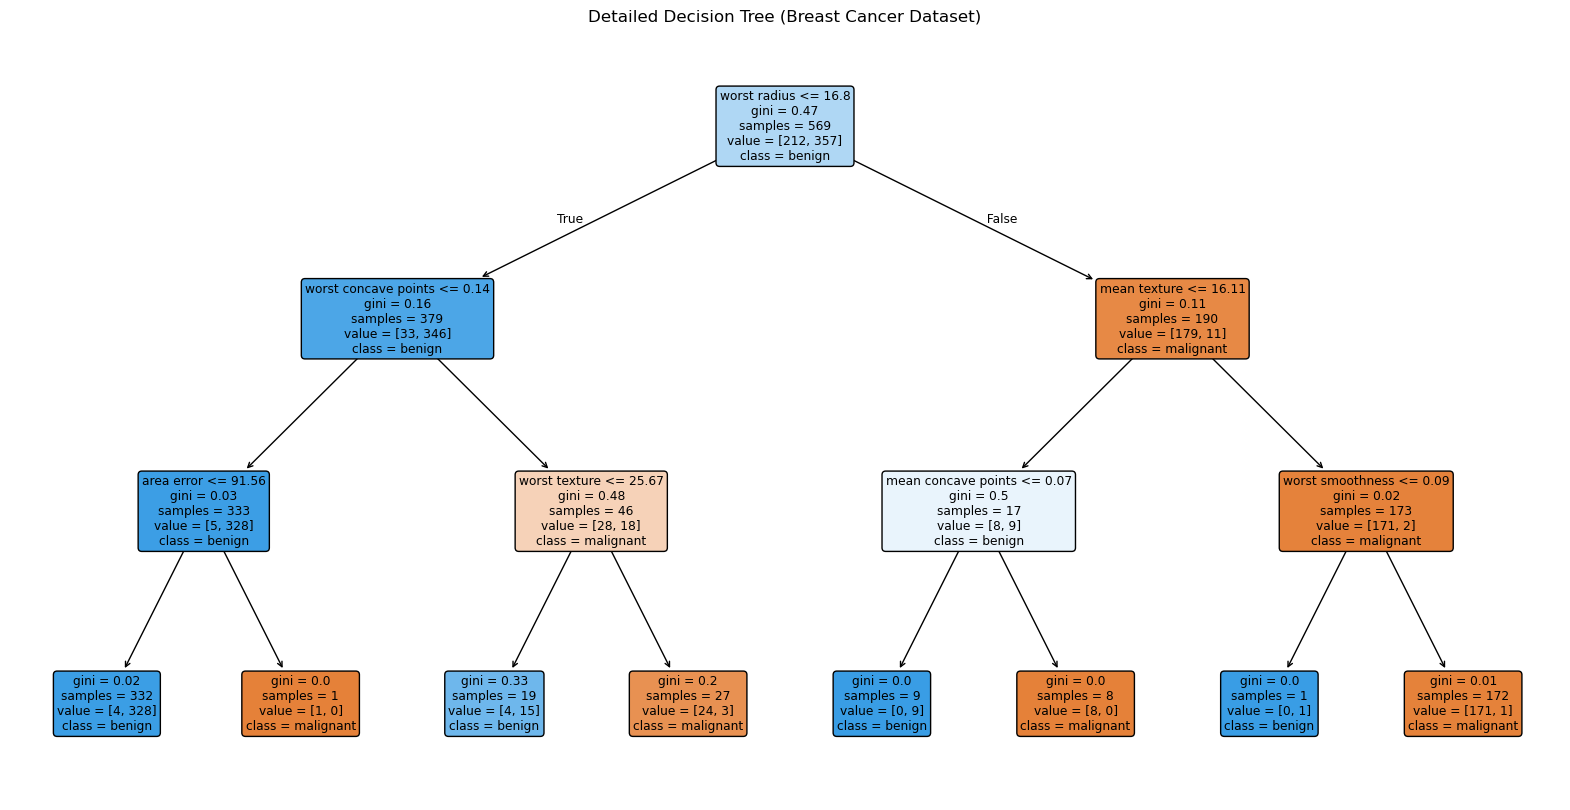

In [28]:
# Let's create a more detailed example to interpret
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

X_cancer = cancer.data
y_cancer = cancer.target

# Create and train a decision tree
cancer_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
cancer_tree.fit(X_cancer, y_cancer)

# Plot the tree with detailed node information
plt.figure(figsize=(20, 10))
plot_tree(cancer_tree, filled=True, feature_names=cancer.feature_names,
          class_names=['malignant', 'benign'], rounded=True, precision=2)
plt.title("Detailed Decision Tree (Breast Cancer Dataset)")
plt.show()

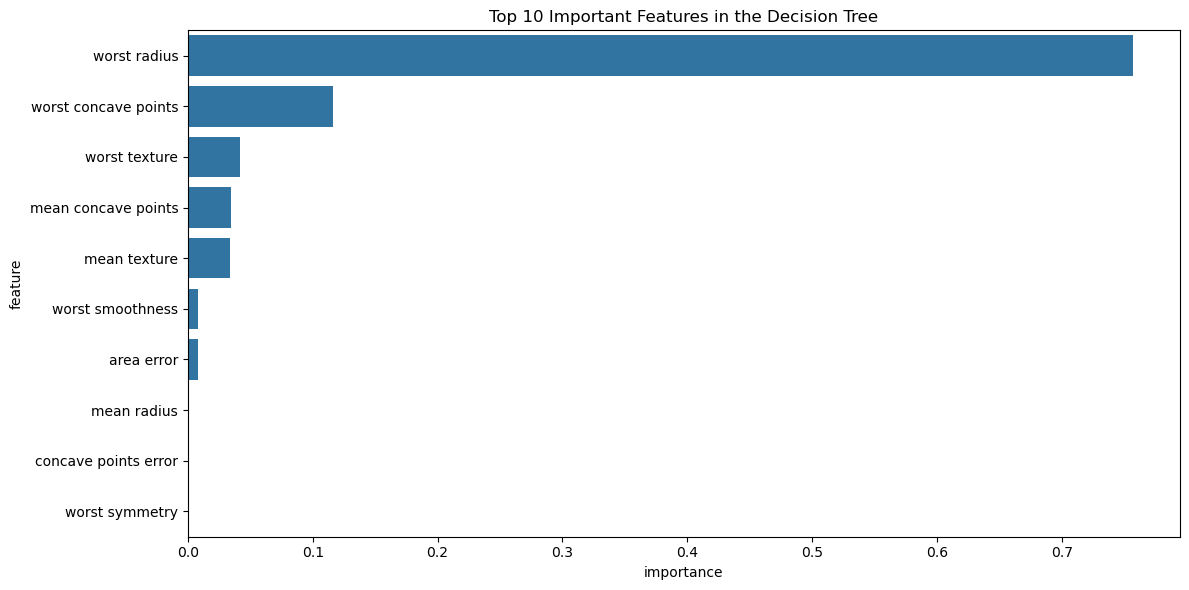

Top 5 most important features:
                 feature  importance
20          worst radius    0.756881
27  worst concave points    0.116533
21         worst texture    0.041982
7    mean concave points    0.034647
1           mean texture    0.033957


In [29]:
# Let's interpret the most important splits
feature_importance = cancer_tree.feature_importances_
features_df = pd.DataFrame({
    'feature': cancer.feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=features_df.head(10))
plt.title('Top 10 Important Features in the Decision Tree')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(features_df.head(5))

### Knowledge Check: Visualizing Decision Trees
1. What information is typically displayed in a decision tree visualization?
2. Why might a text representation be useful for very large trees?
3. What can we learn from the feature importances derived from a decision tree?
4. How can you identify potential overfitting by examining a tree visualization?
5. When interpreting a node in a decision tree visualization, what do the different numbers typically represent?

## Comparison with Previously Learned Models

Let's compare decision trees with models we've previously covered like linear regression, logistic regression, and k-NN.

| Aspect | Decision Trees | Linear/Logistic Regression | k-NN |
|--------|---------------|----------------------------|------|
| Model Type | Non-parametric | Parametric | Non-parametric |
| Decision Boundary | Axis-parallel rectangles | Linear | Local, flexible |
| Interpretability | High | Medium (coefficients) | Low |
| Handling Non-linearity | Good | Poor (without transformations) | Good |
| Scaling Requirements | Not necessary | Important | Critical |
| Handling Categorical Data | Good | Requires encoding | Requires careful handling |
| Handling Missing Values | Extensions available | Requires imputation | Requires imputation |
| Computational Complexity | O(n_features * n_samples * log(n_samples)) | O(n_features * n_samples) | O(n_samples * n_features) for training, O(n * n_features) for prediction |
| Prone to Overfitting | Yes, significantly | Less so | Yes, with small k |

In [31]:
# Let's compare decision trees with previous models on a dataset
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

# Use Iris dataset for comparison
iris = load_iris()
X = iris.data
y = iris.target

# Binary classification for simplicity (just two classes)
# Let's use classes 0 and 1
binary_mask = y < 2
X_binary = X[binary_mask]
y_binary = y[binary_mask]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42)

# Scale data (for fair comparison)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train models
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(random_state=42)
knn = KNeighborsClassifier(n_neighbors=3)

dt.fit(X_train_scaled, y_train)
lr.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred_dt = dt.predict(X_test_scaled)
y_pred_lr = lr.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)

In [32]:
# Evaluate models
print("Accuracy Comparison:")
print(f"Decision Tree: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Logistic Regression: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"k-NN (k=3): {accuracy_score(y_test, y_pred_knn):.4f}")

print("\nF1 Score Comparison:")
print(f"Decision Tree: {f1_score(y_test, y_pred_dt):.4f}")
print(f"Logistic Regression: {f1_score(y_test, y_pred_lr):.4f}")
print(f"k-NN (k=3): {f1_score(y_test, y_pred_knn):.4f}")

Accuracy Comparison:
Decision Tree: 1.0000
Logistic Regression: 1.0000
k-NN (k=3): 1.0000

F1 Score Comparison:
Decision Tree: 1.0000
Logistic Regression: 1.0000
k-NN (k=3): 1.0000


In [33]:
# Let's visualize decision boundaries for a 2D projection of the data
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d = pca.transform(X_test_scaled)

# Retrain models on 2D data
dt_2d = DecisionTreeClassifier(random_state=42)
lr_2d = LogisticRegression(random_state=42)
knn_2d = KNeighborsClassifier(n_neighbors=3)

dt_2d.fit(X_train_2d, y_train)
lr_2d.fit(X_train_2d, y_train)
knn_2d.fit(X_train_2d, y_train)

# Create meshgrid for decision boundary plotting
h = 0.02  # Step size in mesh
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

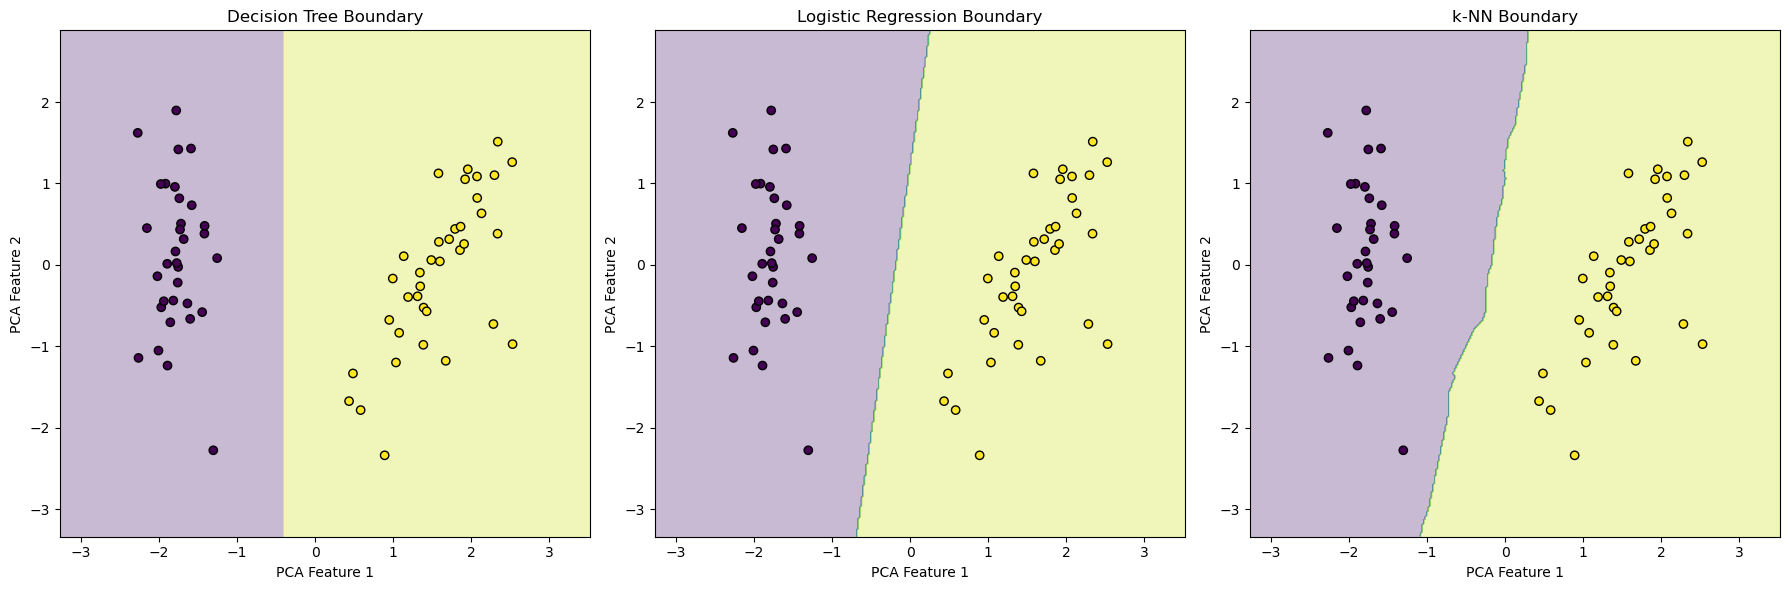

In [34]:
# Plotting function
def plot_decision_boundary(model, title):
    # Predict class for each point in mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolors='k')
    plt.title(title)
    plt.xlabel('PCA Feature 1')
    plt.ylabel('PCA Feature 2')

# Plot decision boundaries
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_decision_boundary(dt_2d, 'Decision Tree Boundary')

plt.subplot(1, 3, 2)
plot_decision_boundary(lr_2d, 'Logistic Regression Boundary')

plt.subplot(1, 3, 3)
plot_decision_boundary(knn_2d, 'k-NN Boundary')

plt.tight_layout()
plt.show()

### When to Choose Decision Trees Over Other Models
- When interpretability is crucial
- When the data has non-linear relationships that are difficult to model with simple transformations
- When features are on very different scales and preprocessing is challenging
- When you need a baseline model before moving to more complex ensemble methods
- When handling mixed data types (numerical and categorical)

### Knowledge Check: Comparing Models
1. How do decision boundaries differ between decision trees and logistic regression?
2. In what scenarios would you prefer decision trees over linear models?
3. What advantage do linear models have over decision trees in terms of stability?
4. How do decision trees and k-NN differ in how they handle the feature space?
5. Which of the compared models would be most affected by feature scaling and why?

## Conclusion

In this notebook, we've explored the fundamental concepts of decision trees for both classification and regression tasks. We've learned:

- The structure and components of decision trees
- How trees make decisions using impurity measures like Gini and Entropy
- The differences between classification and regression trees
- Methods for visualizing and interpreting trees
- How decision trees compare to other machine learning models

In the next notebook (6.2), we'll explore the critical issue of overfitting in decision trees and techniques for complexity control to build more robust models.